# Evaluating all existing submissions

In [14]:
import numpy as np
import pandas as pd
import glob
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load ground truth
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

# Load all submission files
all_outputs = glob.glob('../data/output/*.csv')
all_outputs = sorted(all_outputs)

print(f"Found {len(all_outputs)} submission files:")
for f in all_outputs:
    print(f"  {os.path.basename(f)}")

Found 4 submission files:
  round1_quickRF.csv
  round2_optunaRF.csv
  round3_lightGBM.csv
  round4_linreg_lasso.csv


In [16]:
import json

log_path = '../data/output/cv_scores.json'

with open(log_path, 'r') as f:
    log = json.load(f)

leaderboard = pd.DataFrame(log).sort_values('cv_rmse_mean')

print("=" * 65)
print("📋 MODEL LEADERBOARD")
print("=" * 65)
print(leaderboard[['model', 'cv_rmse_mean', 'cv_rmse_std', 'notes']].to_string(index=False))

📋 MODEL LEADERBOARD
              model  cv_rmse_mean  cv_rmse_std                              notes
    round3_lightGBM       0.12508      0.01264                                   
    round2_optunaRF       0.13614      0.00993                                   
     round1_quickRF       0.14002      0.00995 Baseline RF, simple label encoding
round4_linreg_lasso       0.14885      0.02755                                   


C:\Users\Chyi\AppData\Local\Temp\ipykernel_24736\2654930256.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


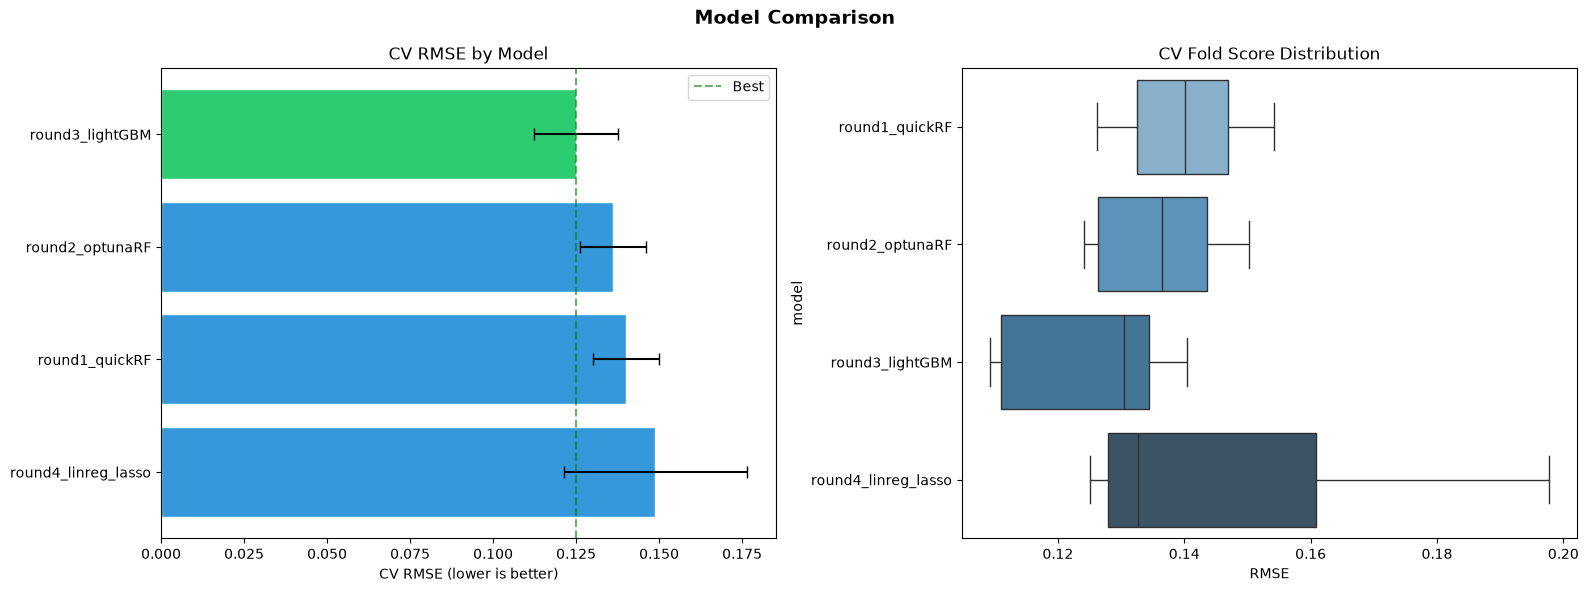

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# ── Bar chart with error bars ────────────────────────────────
colors = ['#2ecc71' if i == 0 else '#3498db'
          for i in range(len(leaderboard))]

axes[0].barh(
    leaderboard['model'],
    leaderboard['cv_rmse_mean'],
    xerr=leaderboard['cv_rmse_std'],
    color=colors,
    edgecolor='white',
    capsize=4
)
axes[0].set_xlabel('CV RMSE (lower is better)')
axes[0].set_title('CV RMSE by Model')
axes[0].axvline(leaderboard['cv_rmse_mean'].min(), color='green',
                linestyle='--', alpha=0.6, label='Best')
axes[0].legend()
axes[0].invert_yaxis()

# ── CV fold scores per model ─────────────────────────────────
fold_data = []
for entry in log:
    for i, score in enumerate(entry['cv_scores']):
        fold_data.append({
            'model' : entry['model'],
            'fold'  : f"Fold {i+1}",
            'rmse'  : score
        })

fold_df = pd.DataFrame(fold_data)

sns.boxplot(
    data=fold_df,
    x='rmse',
    y='model',
    ax=axes[1],
    palette='Blues_d'
)
axes[1].set_xlabel('RMSE')
axes[1].set_title('CV Fold Score Distribution')

plt.tight_layout()
plt.savefig('../plots/model_leaderboard.png', dpi=150)
plt.show()